In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("/content/Salud_mental_agotamiento_estudiantil.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Unnamed: 0            1000000 non-null  int64  
 1   age                   1000000 non-null  int64  
 2   study_hours_per_day   1000000 non-null  float64
 3   exam_pressure         1000000 non-null  float64
 4   academic_performance  1000000 non-null  float64
 5   stress_level          1000000 non-null  float64
 6   anxiety_score         1000000 non-null  float64
 7   depression_score      1000000 non-null  float64
 8   sleep_hours           1000000 non-null  float64
 9   physical_activity     1000000 non-null  float64
 10  social_support        1000000 non-null  float64
 11  screen_time           1000000 non-null  float64
 12  internet_usage        1000000 non-null  float64
 13  financial_stress      1000000 non-null  float64
 14  family_expectation    1000000 non-n

In [ ]:
df.head()

,Unnamed: 0,age,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
0,0,23,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,1.746601
1,1,20,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,0.000000
2,2,29,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,0.696941
3,3,27,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,5.380592
4,4,24,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,0.000000


In [43]:
df.describe()

,age,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,5.001727,5.998810,70.999135,4.246462,2.986413,1.274728,6.501713,3.011153,4.999724,5.018766,5.038116,5.002920,5.983287,1.784073,7.023073,1.324896
std,3.742579,1.989340,1.548268,5.660073,1.678998,1.509844,1.221273,1.472972,1.463679,1.976536,1.960599,2.157838,1.976426,1.960972,1.664035,1.310698,1.342727
min,17.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.530800,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.326226


In [ ]:
X=df['burnout_score'].value_counts().to_frame('conteo')

,conteo
burnout_score,
0.000000,230538
10.000000,9
1.198897,1
0.506286,1
2.941204,1
...,...
1.681644,1
3.450331,1
0.120520,1


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_pct

,0
Unnamed: 0,0.0
age,0.0
study_hours_per_day,0.0
exam_pressure,0.0
academic_performance,0.0
stress_level,0.0
anxiety_score,0.0
depression_score,0.0
sleep_hours,0.0
physical_activity,0.0


Se aprecia como es que el dataset esta limpio y no se necesita imputar ni eliminar datos


In [25]:
# Limpieza inicial: quitar el índice residual y la fila con datos nulos
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df = df.dropna()

# Separar variables numéricas para cálculos globales del dataset original
df_num = df.select_dtypes(include=[np.number])

# Crear la muestra de 10k para gráficos de renderizado pesado (Scatter, KDE)
df_sample = df.sample(n=10000, random_state=42)

# Estilo visual por defecto
sns.set_theme(style="white")

# **Mapa de Calor de Correlación**

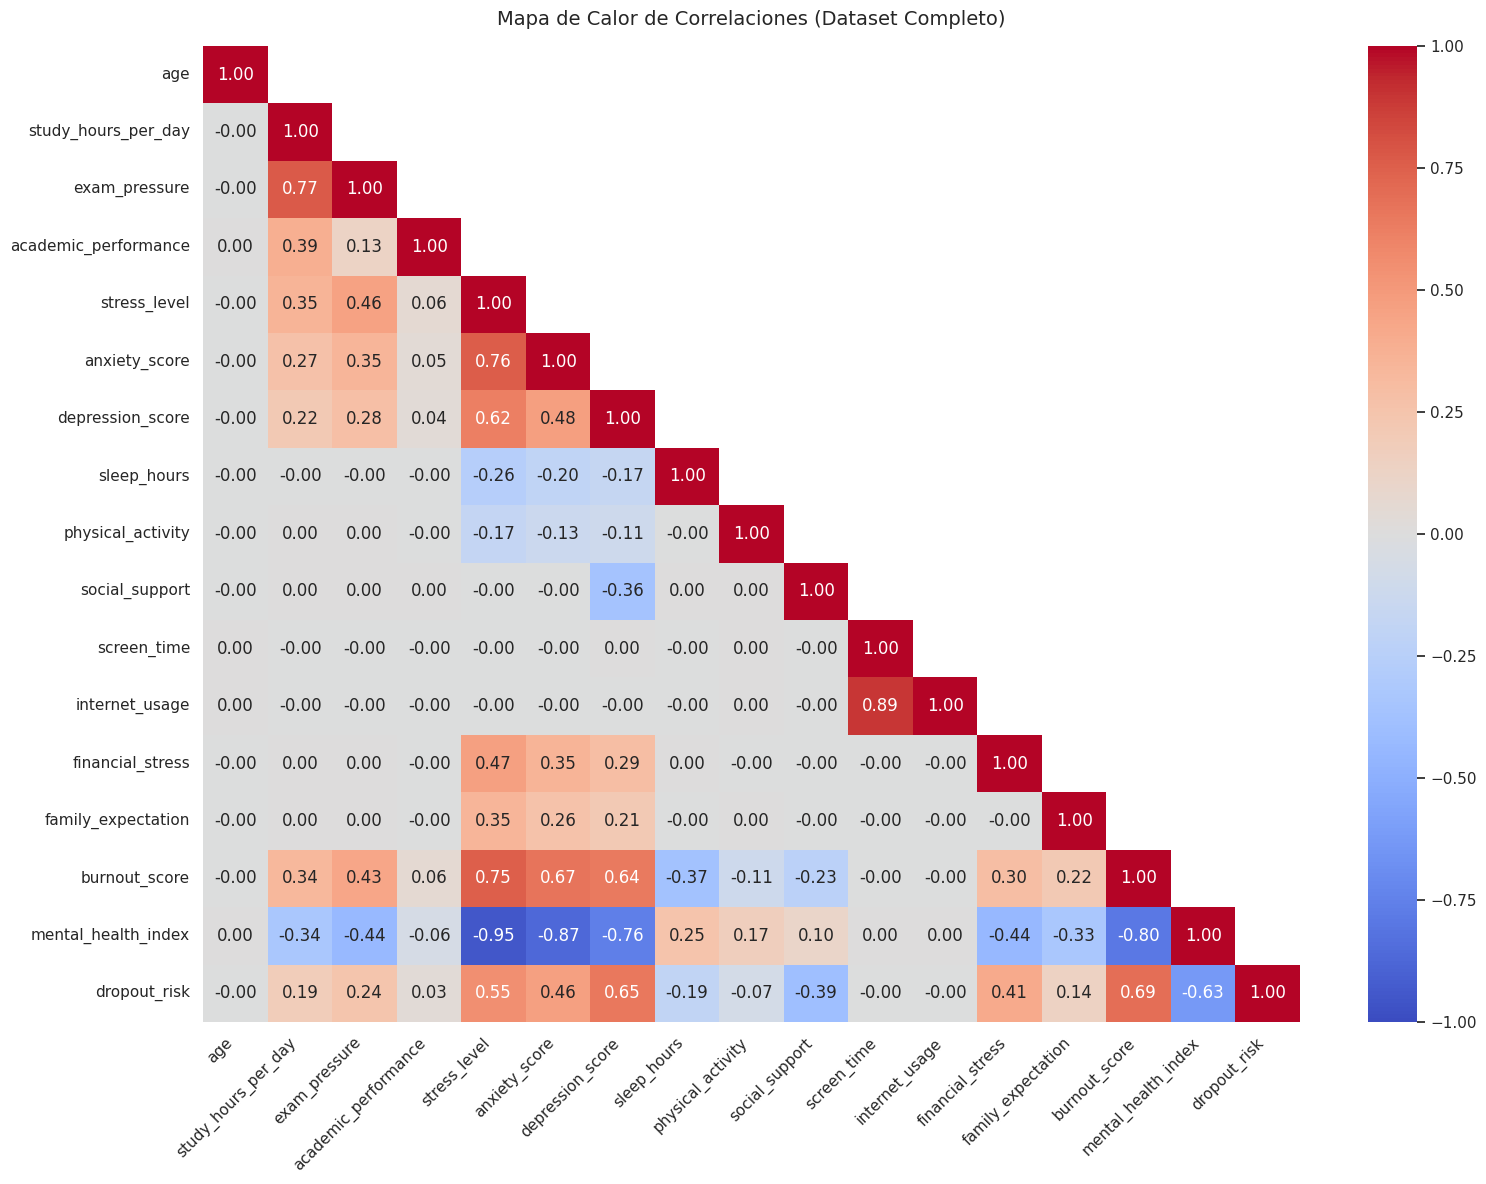

# **Grafico de Dispersión**



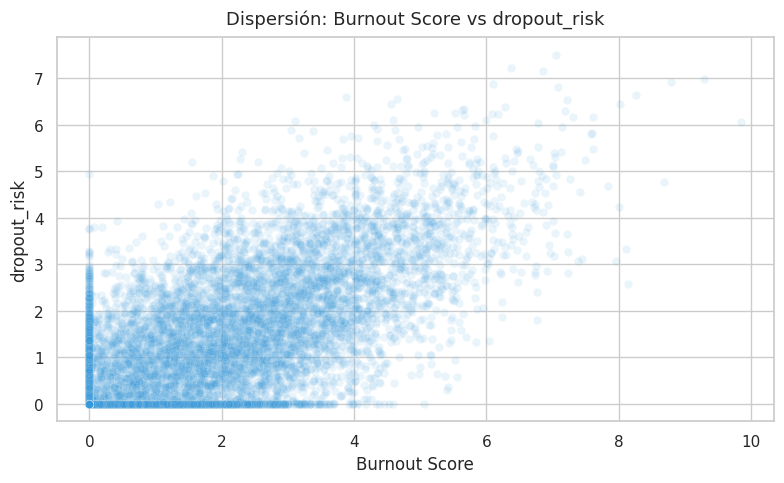

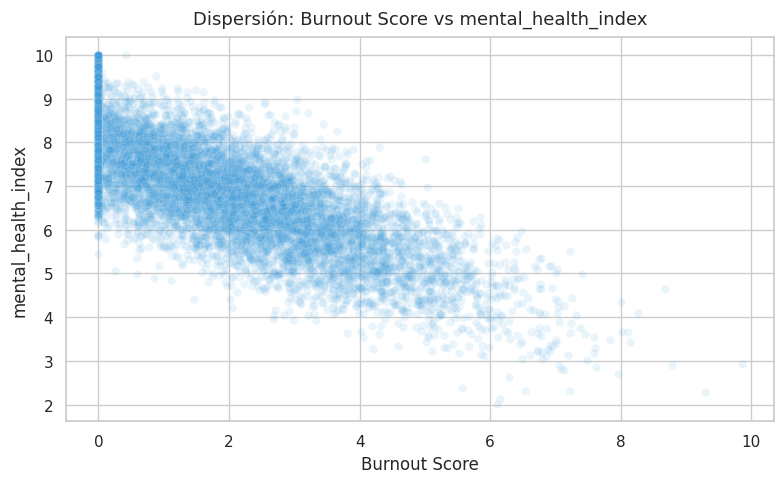

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables que son derivadas del dataset
vars_correlacionadas = [
    'dropout_risk',
    'mental_health_index',
]

# Estilo visual
sns.set_theme(style="whitegrid")

# Bucle para generar un gráfico totalmente separado por cada variable
for var in vars_correlacionadas:
    plt.figure(figsize=(8, 5))

    # Usamos alpha=0.1 para que los puntos superpuestos se vean más oscuros
    # y podamos apreciar la densidad de los datos
    sns.scatterplot(
        data=df_sample,
        x='burnout_score',
        y=var,
        alpha=0.1,
        color='#3498db'
    )

    plt.title(f'Dispersión: Burnout Score vs {var}', fontsize=13, pad=10)
    plt.xlabel('Burnout Score')
    plt.ylabel(var)

    plt.tight_layout()
    plt.show()

Se aprecia que las variables derivadas segun el dataset, se correlacionan altamente con la variable de interes que es Burnout Score. Por ello, se tomo la desicion de eliminarlos del dataset


In [27]:
df_analisis = df.copy()

# Crear el target
df_analisis['riesgo_burnout'] = (df_analisis['burnout_score'] > 4).astype(int)

# Definir columnnas a eliminar
cols_a_eliminar = [
    'Unnamed: 0',        # Ya cumplió su ciclo al transformarse en binaria
    'mental_health_index',  # Derivada inversa
    'dropout_risk',         # Derivada directa

]

# Limpiar el DataFrame
df_analisis = df_analisis.drop(columns=[col for col in cols_a_eliminar if col in df.columns])

# Verificar las columnas que nos quedan para trabajar
print("Columnas listas para el análisis real:", df_analisis.columns.tolist())
print(f"Dimensiones finales del dataset limpio: {df_analisis.shape}")

Columnas listas para el análisis real: ['age', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'riesgo_burnout']
Dimensiones finales del dataset limpio: (1000000, 16)


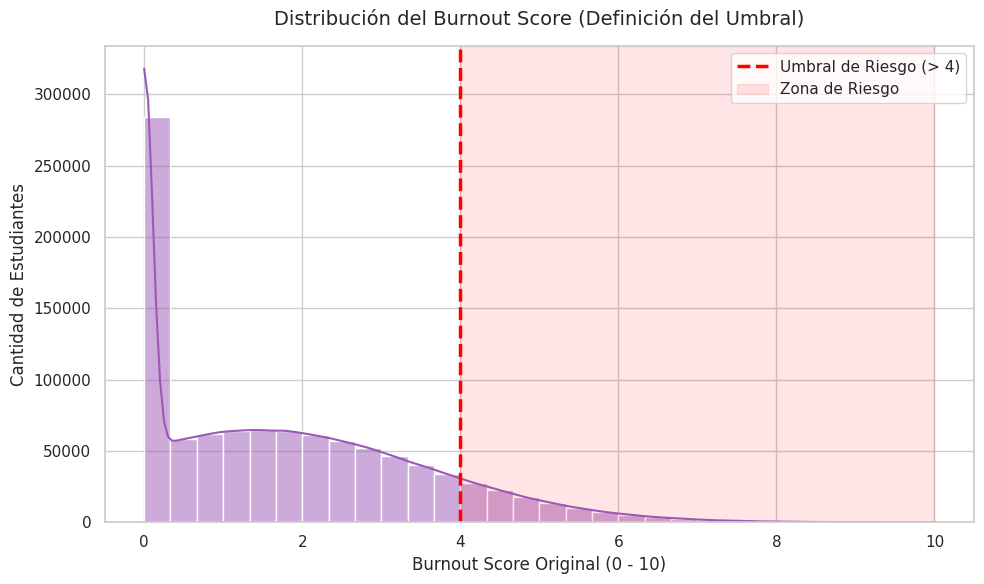

In [28]:
plt.figure(figsize=(10, 6))

# Histograma y curva de densidad del target original
sns.histplot(data=df_analisis, x='burnout_score', kde=True, bins=30, color='#9b59b6')

# Línea del umbral
plt.axvline(x=4, color='red', linestyle='--', linewidth=2.5, label='Umbral de Riesgo (> 4)')

# Sombreado
plt.axvspan(4, 10, color='red', alpha=0.1, label='Zona de Riesgo')

plt.title('Distribución del Burnout Score (Definición del Umbral)', fontsize=14, pad=15)
plt.xlabel('Burnout Score Original (0 - 10)')
plt.ylabel('Cantidad de Estudiantes')
plt.legend()

plt.tight_layout()
plt.show()

# **Distribución del Target (Riesgo Burnout)**

/tmp/ipykernel_34481/3374490040.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_analisis, x='riesgo_burnout', palette='pastel')


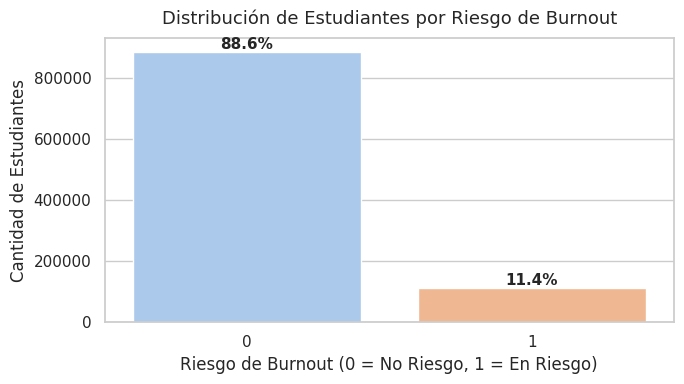

In [29]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df_analisis, x='riesgo_burnout', palette='pastel')
plt.title('Distribución de Estudiantes por Riesgo de Burnout', fontsize=13, pad=10)
plt.xlabel('Riesgo de Burnout (0 = No Riesgo, 1 = En Riesgo)')
plt.ylabel('Cantidad de Estudiantes')

# Calculo de porcentajes
total = len(df_analisis)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(porcentaje, (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Se ve que hay un notorio desbalance de clases.

# **Correlaciones entre Targets**

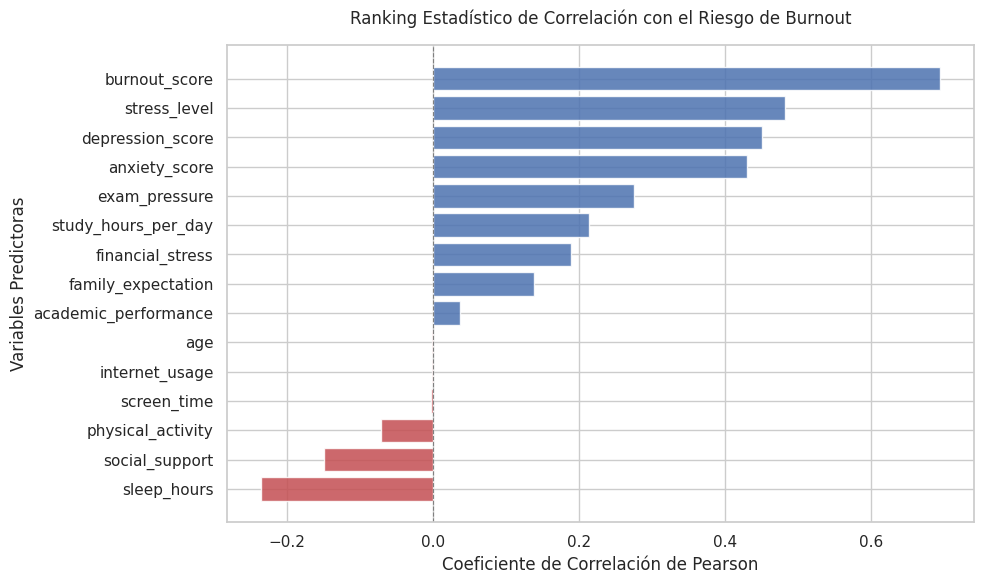

In [30]:
corrs = df_analisis.select_dtypes(include=[np.number]).corr()['riesgo_burnout']
corrs = corrs.drop('riesgo_burnout').sort_values(ascending=True) # De menor a mayor para que quede bien en barra horizontal

# 2. Generar el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Colorear según signo (positivo o negativo)
colores = ['#C44E52' if x < 0 else '#4C72B0' for x in corrs.values]

bars = plt.barh(corrs.index, corrs.values, color=colores, alpha=0.85)

plt.axvline(x=0, color='grey', linestyle='--', linewidth=0.8)
plt.title('Ranking Estadístico de Correlación con el Riesgo de Burnout', fontsize=12, pad=15)
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables Predictoras')
plt.tight_layout()
plt.show()

In [31]:
correlaciones_target = df_analisis.corr()['riesgo_burnout'].sort_values(ascending=False)

print("=== Ranking Estadístico de Correlación con el Riesgo de Burnout ===")
print(correlaciones_target)

# se definio el umbral de correlacion minumo de 0,15
umbral_minimo = 0.15
features_estadisticamente_validas = correlaciones_target[
    (abs(correlaciones_target) >= umbral_minimo) & (correlaciones_target.index != 'riesgo_burnout')
].index.tolist()

print(f"\nVariables seleccionadas objetivamente (|corr| >= {umbral_minimo}):")
print(features_estadisticamente_validas)


=== Ranking Estadístico de Correlación con el Riesgo de Burnout ===
riesgo_burnout          1.000000
burnout_score           0.693974
stress_level            0.481879
depression_score        0.449758
anxiety_score           0.430235
exam_pressure           0.275739
study_hours_per_day     0.213840
financial_stress        0.189692
family_expectation      0.138504
academic_performance    0.037188
age                    -0.000789
internet_usage         -0.001091
screen_time            -0.002015
physical_activity      -0.071580
social_support         -0.148490
sleep_hours            -0.235317
Name: riesgo_burnout, dtype: float64

Variables seleccionadas objetivamente (|corr| >= 0.15):
['burnout_score', 'stress_level', 'depression_score', 'anxiety_score', 'exam_pressure', 'study_hours_per_day', 'financial_stress', 'sleep_hours']


In [32]:
features_validas = [
    'stress_level', 'depression_score', 'anxiety_score',
    'exam_pressure', 'study_hours_per_day', 'financial_stress', 'sleep_hours'
]


Ahora para el analisis grafico nos centraremos en estas variables

# **Blox Plot**

/tmp/ipykernel_34481/257088485.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_34481/257088485.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_34481/257088485.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_34481/257088485.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_34481/257088485.py:12: FutureWarning: 

P

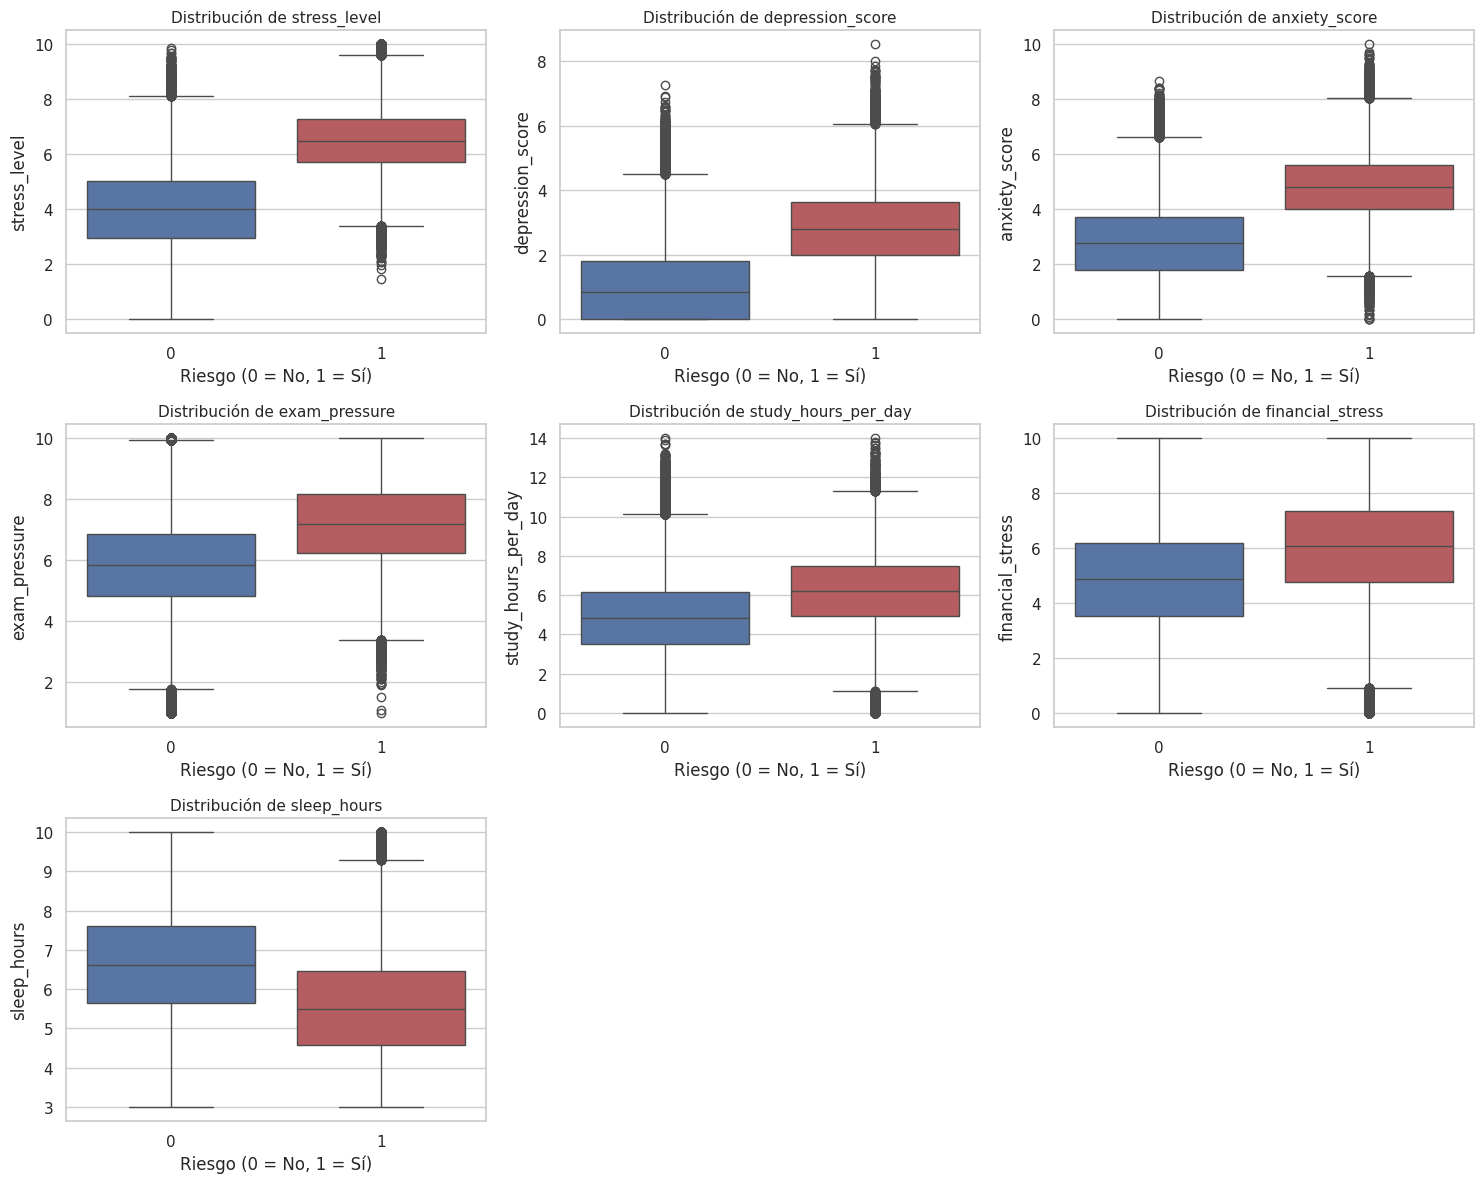

In [33]:
# Configurar la cuadrícula (3 columnas por fila)
num_cols = 3
num_vars = len(features_validas)
num_rows = (num_vars + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()
sns.set_style("whitegrid")

# 3. Generar boxplots bivariados
for i, col in enumerate(features_validas):
    sns.boxplot(
        data=df_analisis,
        x='riesgo_burnout',
        y=col,
        ax=axes[i],
        palette=['#4C72B0', '#C44E52']
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=11)
    axes[i].set_xlabel('Riesgo (0 = No, 1 = Sí)')
    axes[i].set_ylabel(col)

# 4. Limpiar espacios vacíos en la cuadrícula
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Se aprecia como es que hay diferencias entre la poblacion que presenta y no presenta riesgo para estos features

# **Gráfico de Densidad (KDE)**

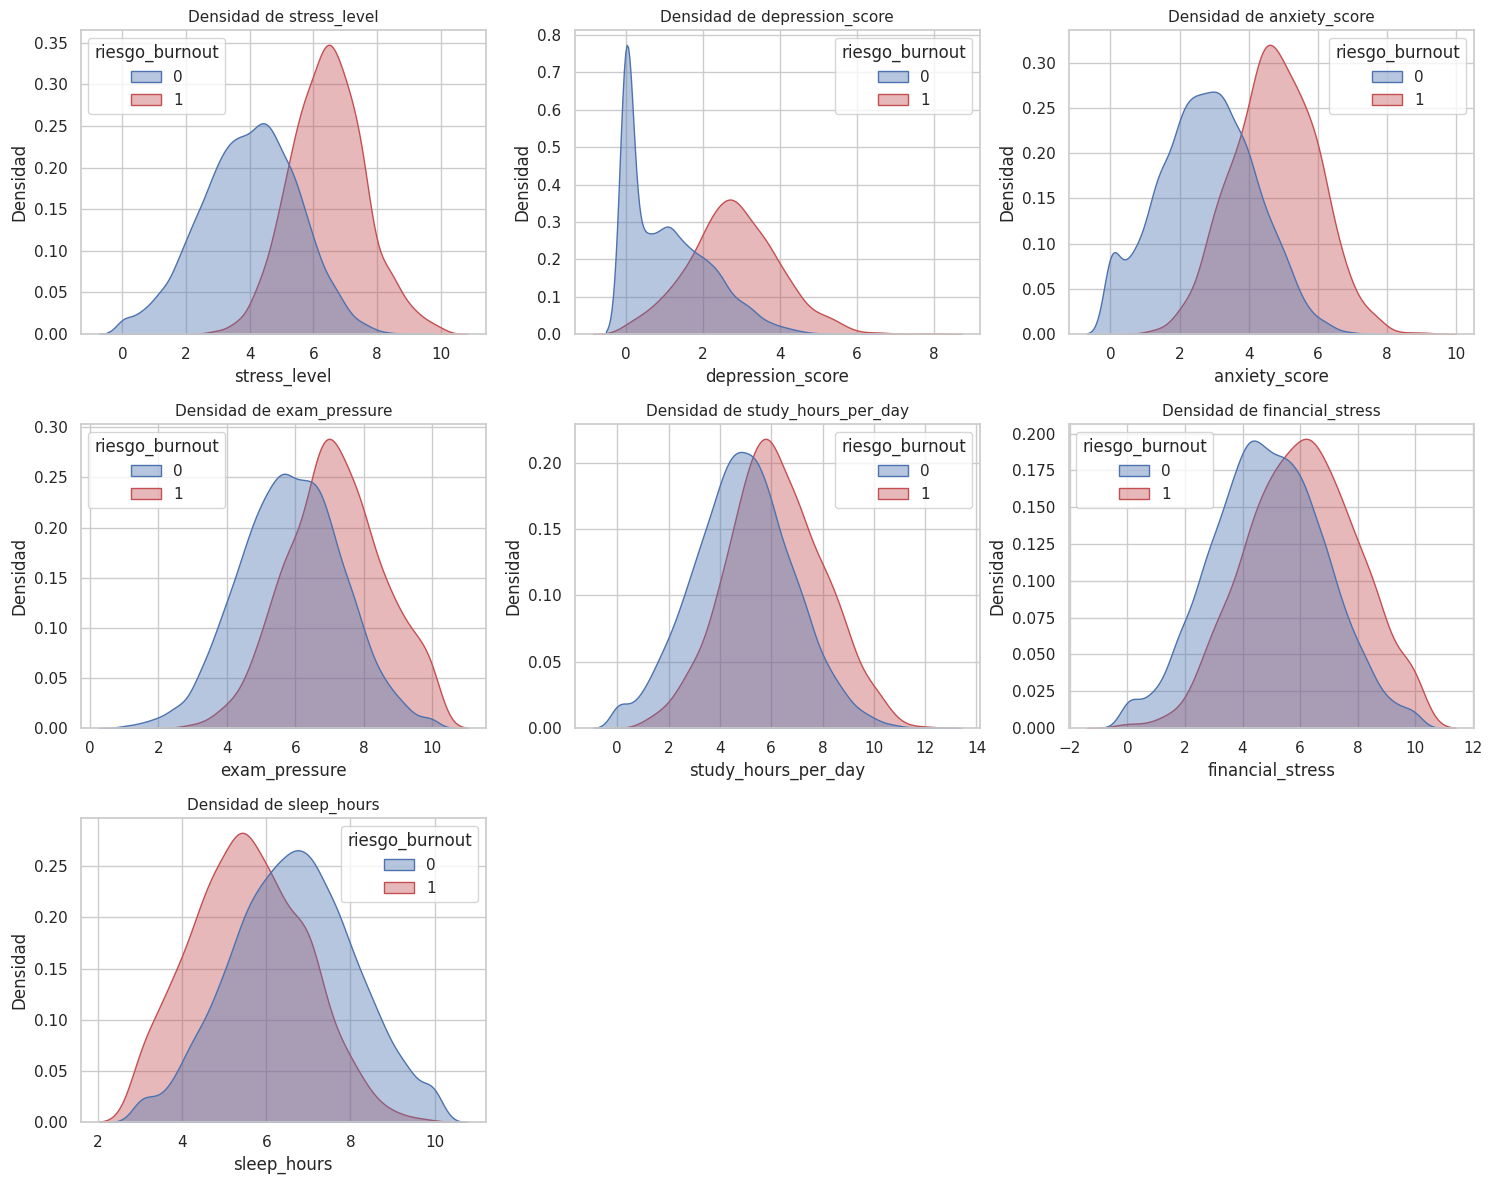

In [34]:
# Muestra para agilizar el renderizado sin perder tendencia estadística
df_muestra = df_analisis.sample(n=10000, random_state=42)

num_cols = 3
num_vars = len(features_validas)
num_rows = (num_vars + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()
sns.set_style("whitegrid")

# Generar gráficos de densidad
for i, col in enumerate(features_validas):
    sns.kdeplot(
        data=df_muestra,
        x=col,
        hue='riesgo_burnout',
        fill=True,
        common_norm=False,
        palette=['#4C72B0', '#C44E52'],
        alpha=0.4,
        ax=axes[i]
    )
    axes[i].set_title(f'Densidad de {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')

# Ocultar espacios vacíos sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# **Varianza**

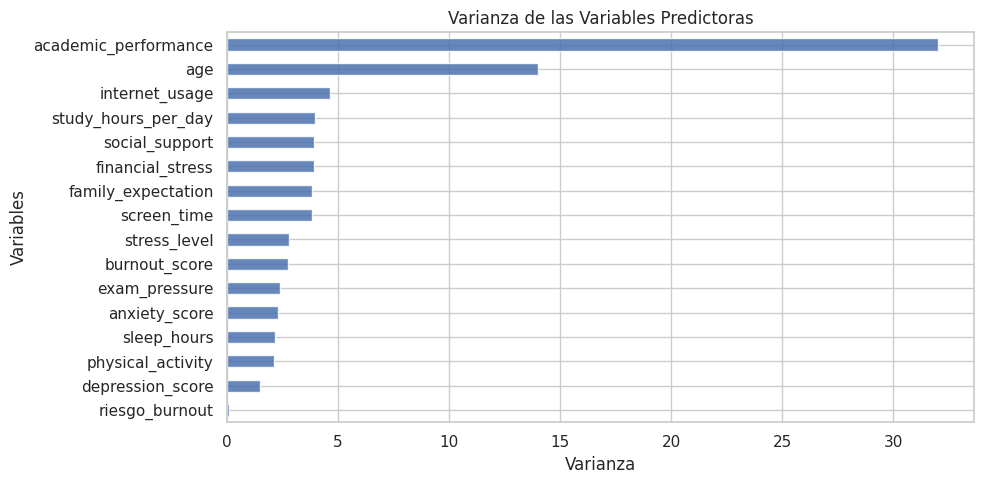

In [35]:
# Calcular la varianza normalizada de cada variable válida
varianzas = df_analisis.var().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
varianzas.plot(kind='barh', color='#4C72B0', alpha=0.85)
plt.title('Varianza de las Variables Predictoras', fontsize=12)
plt.xlabel('Varianza')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

Aqui se aprecia que seria necesario escalar los datos para el procesamiento, sin embargo el modelo a utilizar sera XGboost el cual se basa en arboles de desicion por lo que no es necesario escalar los datos, por ello es que no se estadarizara los datos

# **Grafico VIF**

/tmp/ipykernel_34481/1162831686.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


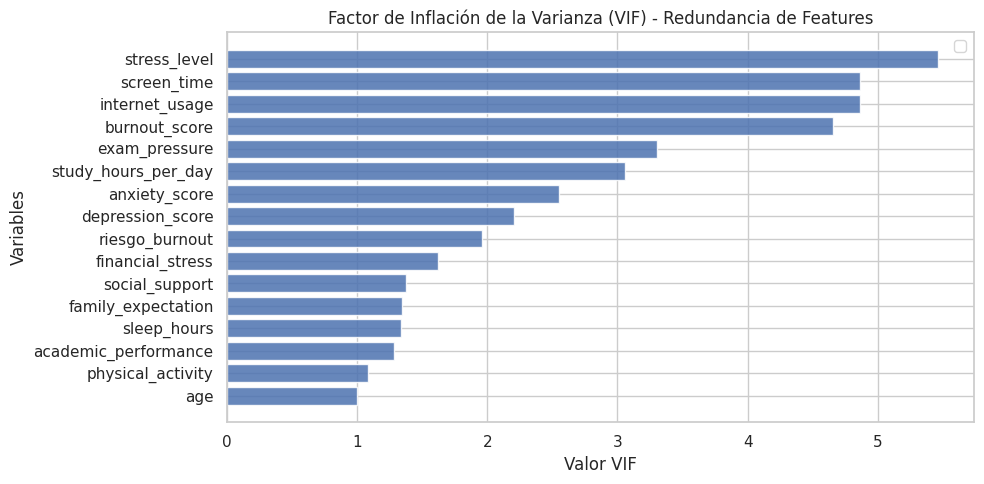

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Preparar los datos sin nulos para el cálculo
X_vif = df_analisis.dropna()

# 2. Calcular el VIF para cada variable predictora
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=True)

# 3. Generar el gráfico de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(vif_data["Feature"], vif_data["VIF"], color='#4C72B0', alpha=0.85)


plt.title('Factor de Inflación de la Varianza (VIF) - Redundancia de Features', fontsize=12)
plt.xlabel('Valor VIF')
plt.ylabel('Variables')
plt.legend()
plt.tight_layout()
plt.show()

Aqui se vuelve a apreciar lo redundante que son la variable internet time y screen time

# **Mapa de calor (variables con correlacion alta)**

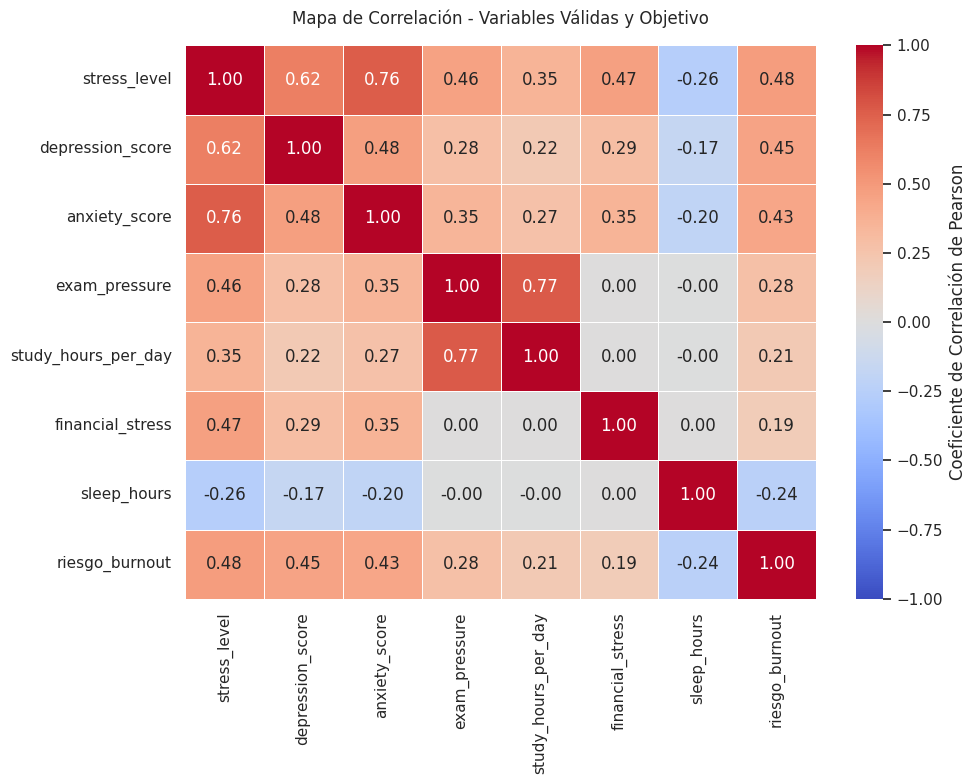

In [38]:
# Incluir las variables válidas y la variable objetivo
cols_a_graficar = features_validas + ['riesgo_burnout']

# Calcular la matriz de correlación solo para este subconjunto
corr_matriz = df_analisis[cols_a_graficar].corr()

# Generar el mapa de calor
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

sns.heatmap(
    corr_matriz,
    annot=True,        # Muestra el valor numérico exacto dentro de cada cuadro
    cmap='coolwarm',   # Paleta de colores (azul = inverso, rojo = directo)
    fmt=".2f",         # Dos decimales
    vmin=-1,
    vmax=1,            # Escala fija de -1 a 1
    linewidths=0.5,    # Líneas divisorias sutiles entre celdas
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Mapa de Correlación - Variables Válidas y Objetivo', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

Se aprecia que no hay variables que tengna una correlacion mayor a 0.8 entre ellas.

Después de realizar el análisis correspondiente, se decidió que se eliminarán las columnas "mental_health_index", "dropout_risk" debido a que son variables derivadas y se verificó que afectarían directamente al target. Por otro lado, se decidió eliminar la columna "internet_usage", esto debido a que se pudo identificar que su correlación con la variable "screen_time" es muy alta (0,89) y es la que menos correlación tiene con el target. Por último, se identificó que la correlación con el target es muy baja para las siguientes columnas: "academic_performance", "age", "screen_time", cuya correlación era menor a 0,05. Por ello, se decidió eliminar todas estas columnas. Por otro lado, también se identificó un desbalance entre las clasificaciones del target; sin embargo, el balance se realizará en la configuración del modelo XGBoost. Por último, también se identificó un desbalance de escala entre algunos features; sin embargo, no genera un problema debido a que se utilizará un modelo XGBoost, el cual está basado en árboles de decisión.

Se procedera a preparar el dataset para ser utilizado en el modelo

In [52]:
# 1. Lista de columnas a eliminar según las conclusiones del EDA
columnas_a_eliminar = [
    "mental_health_index",
    "dropout_risk",
    "internet_usage",
    "academic_performance",
    "age",
    "screen_time",
    "burnout_score"
]

# 2. Aplicar la limpieza asegurándose de que las columnas existan en el DataFrame
columnas_existentes = [col for col in columnas_a_eliminar if col in df_analisis.columns]
df_final = df_analisis.drop(columns=columnas_existentes).copy()

# 3. Definir tu matriz de características (X) y tu variable objetivo (y)
# Suponiendo que tu target se llama 'riesgo_burnout'
X = df_final.drop(columns=['riesgo_burnout'])
y = df_final['riesgo_burnout']

# 4. Verificación rápida del resultado final
print(f"Dataset listo para modelar.")
print(f"Número de filas: {X.shape[0]}")
print(f"Número de features definitivas: {X.shape[1]}")
print(f"Features conservadas: {list(X.columns)}")
print(f"Target: {y.name}")

Dataset listo para modelar.
Número de filas: 1000000
Número de features definitivas: 10
Features conservadas: ['study_hours_per_day', 'exam_pressure', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'financial_stress', 'family_expectation']
Target: riesgo_burnout


In [53]:
# 1. Definir el nombre del archivo
nombre_archivo = "dataset_burnout_limpio.csv"

# 2. Unir X e y si quieres exportar el dataset completo ya depurado con su target
df_final['riesgo_burnout'] = y.values # Asegurando que el target esté incluido

# 3. Guardar como CSV
df_final.to_csv(nombre_archivo, index=False)
print(f"¡Archivo '{nombre_archivo}' guardado exitosamente!")

# 4. Si estás en Google Colab, esto descarga el archivo automáticamente a tu computadora
from google.colab import files
files.download(nombre_archivo)

¡Archivo 'dataset_burnout_limpio.csv' guardado exitosamente!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>